# IT Security Agent — Week 1
### NVD-Based Vulnerability Scanning Agent for SBOMs & Container Images

**Course:** AI & Ethics — IT Security Agent project
**Presentation format:** 10–15 min/group, individually graded, weekly

This notebook is this week's graded deliverable. It follows the standing
weekly reporting format required every week, followed by the four items
required specifically for Week 1.


## Weekly Status

### What did you do throughout the week?
- Scoped the project: an agent that ingests **SBOMs (CycloneDX/SPDX)** and
  **container images**, identifies the software components they contain, and
  matches those components against **NVD** vulnerability data (CVEs).
- Connected to the live **NVD REST API 2.0** and pulled a working sample of
  real CVE data (no local/offline feed files were available or used).
- Analyzed the sample: severity distribution, weakness (CWE) categories,
  vendor/product frequency, publication volume trend, and — most importantly —
  how much of the data has *structured* (machine-matchable) CPE identifiers
  versus free-text only.
- Used those findings to derive a multi-week project plan, a candidate system
  architecture, and an EU-focused regulatory analysis.

### What were your challenges?
- **NVD's legacy bulk JSON data feed files were deprecated in December 2023.**
  The only current integration path is the REST API 2.0, which is
  rate-limited (5 requests/30s without an API key, 50/30s with one). Any
  real deployment needs an incremental local sync rather than live per-scan
  lookups.
- **SBOMs identify packages by purl (package URL); NVD identifies software by
  CPE.** These are not a 1:1 mapping. Our data pull specifically measured how
  many CVEs carry structured CPE match data, and how that coverage varies by
  ecosystem — this turned out to be the single biggest open design question.
- Scoping a regulatory analysis before a concrete system exists — we grounded
  it in the current EU project shape (SBOM handling, vulnerability
  reporting, and a later LLM-assisted layer) rather than a finished product.

### What are your next steps?
- Week 2: build the SBOM (CycloneDX/SPDX) parser and container image package
  extractor, and normalize both into one internal component representation.
- Week 3: build a local NVD sync service and the purl↔CPE matching engine.
- Week 4: enrichment (CVSS/CWE/CISA KEV) and report generation.
- Week 5+: LLM-assisted explanation/prioritization layer (the "agent"
  behavior) and evaluation against known-vulnerable test images/SBOMs.


---
## 1. Data Analysis

We pull a live sample directly from the **NVD REST API 2.0**
(`https://services.nvd.nist.gov/rest/json/cves/2.0`). Two kinds of pulls:

1. **Recency sample** — CVEs *published* in the last 90 days (up to 2000
   records in one page), to look at overall severity/CWE/volume patterns.
2. **Ecosystem samples** — small keyword-scoped pulls for `npm`, `python`,
   `java`/maven, and `debian`/`alpine`, since these ecosystems dominate real
   SBOMs and container images. Used specifically to check structured CPE
   coverage per ecosystem.

We stay well under the public rate limit by spacing requests ~6 seconds
apart.


In [1]:
import time
import datetime as dt
import requests
import pandas as pd
import matplotlib.pyplot as plt

NVD_BASE = "https://services.nvd.nist.gov/rest/json/cves/2.0"
REQUEST_SPACING_SECONDS = 6  # public rate limit: 5 requests / 30s

def nvd_get(params, retries=3):
    for attempt in range(retries):
        resp = requests.get(NVD_BASE, params=params, timeout=30)
        if resp.status_code == 200:
            return resp.json()
        if resp.status_code == 403 and attempt < retries - 1:
            time.sleep(REQUEST_SPACING_SECONDS * 2)
            continue
        resp.raise_for_status()
    raise RuntimeError("NVD request failed after retries")


In [2]:
# --- 1a. Recency sample: CVEs published in the last 90 days ---
now = dt.datetime.utcnow()
pub_end = now
pub_start = now - dt.timedelta(days=90)

recent_raw = nvd_get({
    "pubStartDate": pub_start.strftime("%Y-%m-%dT%H:%M:%S.000"),
    "pubEndDate": pub_end.strftime("%Y-%m-%dT%H:%M:%S.000"),
    "resultsPerPage": 2000,
    "startIndex": 0,
})

print("Total CVEs published in window:", recent_raw["totalResults"])
print("Sample size fetched:", len(recent_raw["vulnerabilities"]))


Total CVEs published in window: 20823
Sample size fetched: 2000


In [3]:
# --- 1b. Ecosystem samples via keyword search ---
time.sleep(REQUEST_SPACING_SECONDS)

ECOSYSTEM_KEYWORDS = {
    "npm/JavaScript": "npm",
    "PyPI/Python": "python",
    "Maven/Java": "java",
    "Debian/Alpine (OS packages)": "debian",
}

ecosystem_raw = {}
for label, keyword in ECOSYSTEM_KEYWORDS.items():
    data = nvd_get({
        "keywordSearch": keyword,
        "resultsPerPage": 200,
        "startIndex": 0,
    })
    ecosystem_raw[label] = data
    print(f"{label:30s} totalResults={data['totalResults']:>7}  sampled={len(data['vulnerabilities'])}")
    time.sleep(REQUEST_SPACING_SECONDS)


npm/JavaScript                 totalResults=    292  sampled=200


PyPI/Python                    totalResults=   1629  sampled=200


Maven/Java                     totalResults=  11768  sampled=200


Debian/Alpine (OS packages)    totalResults=    250  sampled=200


### Parsing into a flat DataFrame

For each CVE we extract: ID, published/modified dates, CVSS base score &
severity (preferring v3.1, falling back to v3.0 then v2), CWE weakness IDs,
and whether the record has structured CPE `configurations` data (and if so,
the vendor/product names parsed out of the CPE 2.3 URI).


In [4]:
def best_cvss(metrics):
    for key in ("cvssMetricV31", "cvssMetricV30", "cvssMetricV2"):
        if metrics.get(key):
            m = metrics[key][0]
            data = m.get("cvssData", {})
            return data.get("baseScore"), m.get("baseSeverity", data.get("baseSeverity"))
    return None, None

def cwe_ids(weaknesses):
    ids = []
    for w in weaknesses or []:
        for d in w.get("description", []):
            if d.get("lang") == "en" and d.get("value", "").startswith("CWE-"):
                ids.append(d["value"])
    return ids

def cpe_vendor_products(configurations):
    pairs = []
    for node_group in configurations or []:
        for node in node_group.get("nodes", []):
            for match in node.get("cpeMatch", []):
                criteria = match.get("criteria", "")
                parts = criteria.split(":")
                if len(parts) > 4:
                    pairs.append((parts[3], parts[4]))  # vendor, product
    return pairs

def parse_cve_record(item):
    cve = item["cve"]
    score, severity = best_cvss(cve.get("metrics", {}))
    vp = cpe_vendor_products(cve.get("configurations"))
    return {
        "id": cve["id"],
        "published": cve.get("published"),
        "last_modified": cve.get("lastModified"),
        "cvss_score": score,
        "severity": severity,
        "cwe_ids": cwe_ids(cve.get("weaknesses")),
        "has_structured_cpe": len(vp) > 0,
        "vendors": [v for v, _ in vp],
        "products": [p for _, p in vp],
    }

recent_df = pd.DataFrame(parse_cve_record(item) for item in recent_raw["vulnerabilities"])
recent_df["published"] = pd.to_datetime(recent_df["published"])
recent_df.head()


,id,published,last_modified,cvss_score,severity,cwe_ids,has_structured_cpe,vendors,products
0,CVE-2025-14938,2026-04-04 12:16:01.450,2026-06-17T08:36:48.143,5.3,MEDIUM,[CWE-434],False,[],[]
1,CVE-2026-0626,2026-04-04 12:16:02.787,2026-06-17T10:11:06.337,6.4,MEDIUM,[CWE-79],False,[],[]
2,CVE-2026-1233,2026-04-04 12:16:02.943,2026-06-17T10:15:22.280,7.5,HIGH,[CWE-798],False,[],[]
3,CVE-2026-2936,2026-04-04 12:16:03.090,2026-06-17T10:32:04.267,7.2,HIGH,[CWE-79],False,[],[]
4,CVE-2026-3309,2026-04-04 12:16:03.237,2026-06-17T10:43:23.180,6.5,MEDIUM,[CWE-94],False,[],[]


In [5]:
ecosystem_df = pd.concat(
    [
        pd.DataFrame(parse_cve_record(item) for item in data["vulnerabilities"]).assign(ecosystem=label)
        for label, data in ecosystem_raw.items()
    ],
    ignore_index=True,
)
ecosystem_df.head()


,id,published,last_modified,cvss_score,severity,cwe_ids,has_structured_cpe,vendors,products,ecosystem
0,CVE-2016-3956,2016-07-02T14:59:19.417,2026-06-17T00:46:38.163,7.5,HIGH,[CWE-200],True,"[ibm, ibm, ibm, nodejs, nodejs, nodejs, nodejs...","[sdk, sdk, sdk, node.js, node.js, node.js, nod...",npm/JavaScript
1,CVE-2016-3012,2016-12-01T11:59:04.713,2026-06-17T00:44:49.017,7.5,HIGH,[CWE-200],True,"[ibm, ibm]","[api_connect, network_path_manager]",npm/JavaScript
2,CVE-2017-8914,2017-05-23T04:29:02.290,2026-06-17T01:27:11.540,8.3,HIGH,[],True,"[sap, sap]","[hana_xs, hana_xs]",npm/JavaScript
3,CVE-2017-1000219,2017-11-17T00:29:00.247,2026-06-17T00:58:55.723,9.8,CRITICAL,[CWE-78],True,"[windows-cpu_project, windows-cpu_project]","[windows-cpu, windows-cpu]",npm/JavaScript
4,CVE-2016-10703,2017-12-14T19:29:00.197,2026-06-17T00:40:11.640,7.5,HIGH,[CWE-20],True,[ecstatic_project],[ecstatic],npm/JavaScript


### 1a. CVSS severity distribution (last-90-days sample)

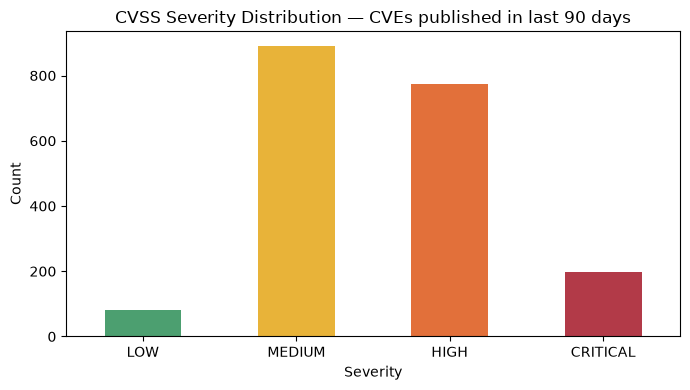

severity
LOW          80
MEDIUM      891
HIGH        773
CRITICAL    197
Name: count, dtype: int64

CVEs with no CVSS score at all: 58 / 2000 (2.9%)


In [6]:
severity_order = ["LOW", "MEDIUM", "HIGH", "CRITICAL"]
counts = recent_df["severity"].value_counts().reindex(severity_order).fillna(0)

fig, ax = plt.subplots(figsize=(7, 4))
counts.plot(kind="bar", ax=ax, color=["#4C9F70", "#E8B339", "#E2703A", "#B23A48"])
ax.set_title("CVSS Severity Distribution — CVEs published in last 90 days")
ax.set_xlabel("Severity")
ax.set_ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print(counts)
missing_score = recent_df["cvss_score"].isna().sum()
print(f"\nCVEs with no CVSS score at all: {missing_score} / {len(recent_df)} "
      f"({missing_score/len(recent_df):.1%})")


### 1b. Top CWE (weakness) categories

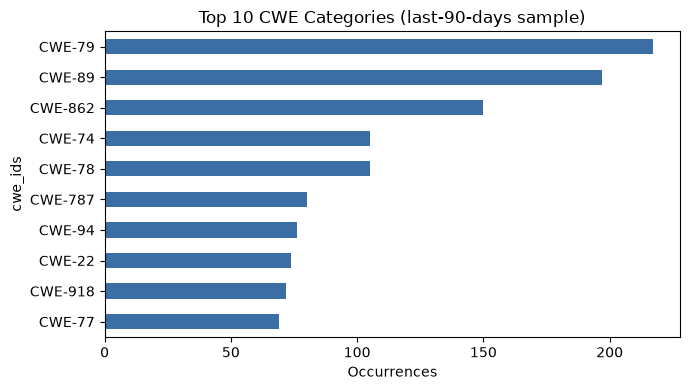

cwe_ids
CWE-79     217
CWE-89     197
CWE-862    150
CWE-78     105
CWE-74     105
CWE-787     80
CWE-94      76
CWE-22      74
CWE-918     72
CWE-77      69
Name: count, dtype: int64

In [7]:
cwe_series = recent_df["cwe_ids"].explode().dropna()
top_cwe = cwe_series.value_counts().head(10)

fig, ax = plt.subplots(figsize=(7, 4))
top_cwe.sort_values().plot(kind="barh", ax=ax, color="#3B6EA5")
ax.set_title("Top 10 CWE Categories (last-90-days sample)")
ax.set_xlabel("Occurrences")
plt.tight_layout()
plt.show()

top_cwe


### 1c. Top vendors/products referenced in structured CPE data

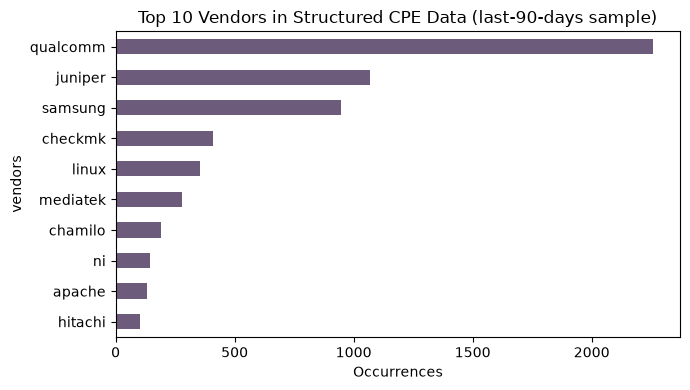

vendors
qualcomm    2258
juniper     1069
samsung      947
checkmk      410
linux        354
mediatek     280
chamilo      189
ni           145
apache       130
hitachi      104
Name: count, dtype: int64

In [8]:
top_vendors = recent_df["vendors"].explode().dropna().value_counts().head(10)

fig, ax = plt.subplots(figsize=(7, 4))
top_vendors.sort_values().plot(kind="barh", ax=ax, color="#6C5B7B")
ax.set_title("Top 10 Vendors in Structured CPE Data (last-90-days sample)")
ax.set_xlabel("Occurrences")
plt.tight_layout()
plt.show()

top_vendors


### 1d. Publication volume trend

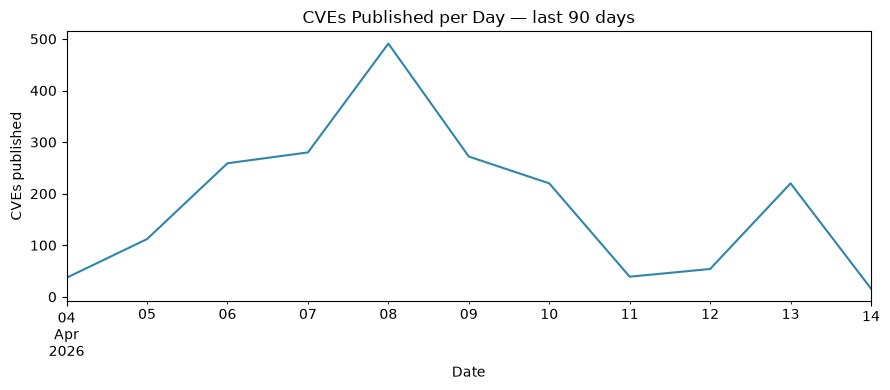

Mean CVEs/day: 181.8   Max CVEs/day: 491


In [9]:
daily_counts = recent_df.set_index("published").resample("D").size()

fig, ax = plt.subplots(figsize=(9, 4))
daily_counts.plot(ax=ax, color="#2E86AB")
ax.set_title("CVEs Published per Day — last 90 days")
ax.set_xlabel("Date")
ax.set_ylabel("CVEs published")
plt.tight_layout()
plt.show()

print(f"Mean CVEs/day: {daily_counts.mean():.1f}   Max CVEs/day: {daily_counts.max()}")


### 1e. Structured CPE match coverage — the key architectural finding

This is the metric that most directly shapes the architecture: what fraction
of CVEs actually carry structured, machine-matchable CPE data, both overall
and broken down by ecosystem?


Overall structured-CPE coverage (last-90-days sample): 63.4%


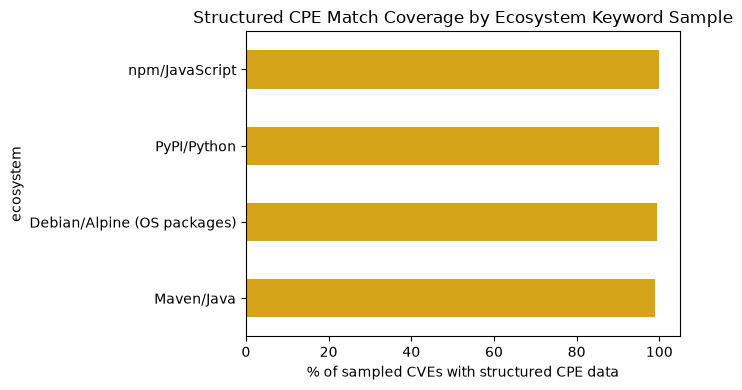

ecosystem
Maven/Java                     0.990
Debian/Alpine (OS packages)    0.995
PyPI/Python                    1.000
npm/JavaScript                 1.000
Name: has_structured_cpe, dtype: float64

In [10]:
overall_coverage = recent_df["has_structured_cpe"].mean()
print(f"Overall structured-CPE coverage (last-90-days sample): {overall_coverage:.1%}")

eco_coverage = ecosystem_df.groupby("ecosystem")["has_structured_cpe"].mean().sort_values()

fig, ax = plt.subplots(figsize=(7, 4))
(eco_coverage * 100).plot(kind="barh", ax=ax, color="#D6A419")
ax.set_title("Structured CPE Match Coverage by Ecosystem Keyword Sample")
ax.set_xlabel("% of sampled CVEs with structured CPE data")
plt.tight_layout()
plt.show()

eco_coverage


**Finding:** structured CPE coverage is uneven across ecosystems and never
complete. Since SBOM tooling identifies components by **purl**, not CPE, a
scanner that only matches on CPE will silently miss a meaningful share of
real-world components — especially language-ecosystem packages (npm/PyPI/Maven)
versus OS packages, which tend to have denser CPE coverage. This finding
directly motivates the hybrid matching engine in the architecture below.


---
## 2. Plan Derived From the Data Analysis

The coverage gap found above means the project cannot rely on CPE matching
alone. The plan below sequences work so the hardest problem (purl↔CPE
matching) is tackled right after basic parsing, not left until the end.


In [11]:
plan = pd.DataFrame([
    ("Week 2", "SBOM & image ingestion",
     "Parse CycloneDX/SPDX SBOMs; extract installed packages from container "
     "image layers; normalize both into one internal component schema "
     "(name, version, ecosystem, purl)."),
    ("Week 3", "NVD sync + matching engine",
     "Incremental local NVD sync via lastModStartDate/EndDate windowing "
     "(avoids per-scan live calls under the rate limit); build the "
     "purl-to-CPE matching engine informed by this week's coverage findings."),
    ("Week 4", "Enrichment & reporting",
     "Attach CVSS severity, CWE category, and CISA KEV (known-exploited) "
     "flags to matches; generate a structured report per scanned SBOM/image."),
    ("Week 5+", "Agent layer & evaluation",
     "LLM-assisted plain-language explanation/prioritization of findings; "
     "evaluate end-to-end against known-vulnerable test images and SBOMs."),
], columns=["Milestone", "Focus", "Details"])
plan


,Milestone,Focus,Details
0,Week 2,SBOM & image ingestion,Parse CycloneDX/SPDX SBOMs; extract installed ...
1,Week 3,NVD sync + matching engine,Incremental local NVD sync via lastModStartDat...
2,Week 4,Enrichment & reporting,"Attach CVSS severity, CWE category, and CISA K..."
3,Week 5+,Agent layer & evaluation,LLM-assisted plain-language explanation/priori...


---
## 3. Possible Architecture

Driven directly by the coverage finding: matching cannot be CPE-only, so the
architecture keeps a local, incrementally-synced NVD cache (required anyway
given the rate limit) and a matching engine that combines direct CPE
matching with a purl-to-CPE mapping layer.


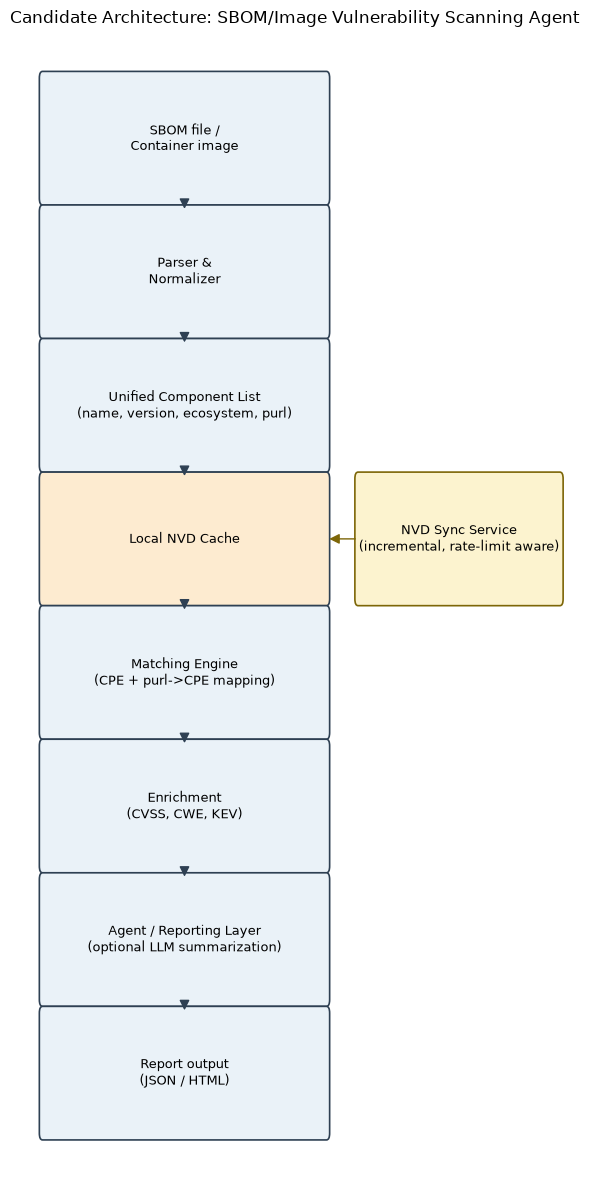

In [12]:
import matplotlib.patches as mpatches
from matplotlib.patches import FancyArrowPatch

stages = [
    "SBOM file /\nContainer image",
    "Parser &\nNormalizer",
    "Unified Component List\n(name, version, ecosystem, purl)",
    "Local NVD Cache",
    "Matching Engine\n(CPE + purl->CPE mapping)",
    "Enrichment\n(CVSS, CWE, KEV)",
    "Agent / Reporting Layer\n(optional LLM summarization)",
    "Report output\n(JSON / HTML)",
]
side_note = "NVD Sync Service\n(incremental, rate-limit aware)"

fig, ax = plt.subplots(figsize=(6, 12))
ax.axis("off")

n = len(stages)
box_h = 0.9
y_positions = list(range(n, 0, -1))

for y, label in zip(y_positions, stages):
    color = "#EAF2F8" if "Cache" not in label else "#FDEBD0"
    box = mpatches.FancyBboxPatch((0.5, y - box_h/2), 4.5, box_h,
                                   boxstyle="round,pad=0.05",
                                   linewidth=1.2, edgecolor="#2E4053",
                                   facecolor=color)
    ax.add_patch(box)
    ax.text(2.75, y, label, ha="center", va="center", fontsize=9)

for y_from, y_to in zip(y_positions[:-1], y_positions[1:]):
    ax.add_patch(FancyArrowPatch((2.75, y_from - box_h/2), (2.75, y_to + box_h/2),
                                  arrowstyle="-|>", mutation_scale=15, color="#2E4053"))

cache_y = y_positions[3]
sync_box = mpatches.FancyBboxPatch((5.5, cache_y - box_h/2), 3.2, box_h,
                                    boxstyle="round,pad=0.05",
                                    linewidth=1.2, edgecolor="#7D6608",
                                    facecolor="#FCF3CF")
ax.add_patch(sync_box)
ax.text(7.1, cache_y, side_note, ha="center", va="center", fontsize=9)
ax.add_patch(FancyArrowPatch((5.5, cache_y), (5.0, cache_y),
                              arrowstyle="-|>", mutation_scale=15, color="#7D6608"))

ax.set_xlim(0, 9)
ax.set_ylim(0.2, n + 0.8)
ax.set_title("Candidate Architecture: SBOM/Image Vulnerability Scanning Agent", fontsize=12)
plt.tight_layout()
plt.show()


**Why a local sync cache instead of live per-scan API calls:** the public NVD
rate limit (5 requests/30s, 50/30s with an API key) makes live lookups per
scanned component impractical at any real scale. Incremental sync
(`lastModStartDate`/`lastModEndDate` windowing) is NVD's own recommended
integration pattern for this reason.

**Why the matching engine is CPE + purl-mapping, not CPE-only:** directly
because of the coverage finding in section 1e — CPE-only matching would miss
a meaningful share of real components, especially in language ecosystems.


---
## 4. Regulatory Analysis (EU-focused)

| Regulation | Relevance to this project |
|---|---|
| **Cyber Resilience Act (CRA)** | Obligates manufacturers of products with digital elements to maintain an SBOM and handle vulnerabilities across the product lifecycle, including reporting actively exploited vulnerabilities to ENISA/CSIRTs (24h early warning, 72h follow-up report). The agent's output — vulnerability findings tied to an SBOM — is exactly the kind of artifact CRA compliance work consumes. |
| **NIS2 Directive** | Imposes supply-chain security and incident-reporting obligations on essential/important entities. A vulnerability-scanning agent is a concrete control supporting NIS2's supply-chain risk management requirement. |
| **GDPR** | Mostly indirect: the agent processes software component metadata, not personal data. Organizational metadata that may appear in scan context (e.g. asset owners, internal hostnames) should still be minimized and access-restricted in reports. |
| **EU AI Act** | The planned Week 5+ LLM-assisted explanation/prioritization layer makes part of the system an "AI system" under the Act. It almost certainly falls under minimal/limited risk (not an Annex III high-risk use case), but transparency obligations (disclosing AI-generated/assisted output) apply once that layer exists. |
| **NVD Terms of Use** | Not legislation, but a binding practical constraint: public API rate limits and attribution expectations directly shape the sync-service design in section 3. |

**Takeaway:** the regulatory picture argues for the same architecture the
data already suggested — an auditable local cache with traceable matching
logic (supports CRA/NIS2 reporting obligations) and a clearly-labeled AI
layer kept separate from the deterministic matching engine (supports EU AI
Act transparency obligations without over-scoping the whole system as
high-risk).


---
## Summary

This week's data pull and analysis turned an abstract goal ("scan SBOMs and
images against NVD") into a concrete, evidence-based architecture: a
locally-synced NVD cache (forced by rate limits) feeding a matching engine
that must bridge purl and CPE identifiers (forced by the coverage gap found
in section 1e), with a clearly separated, EU-AI-Act-aware layer for any
future LLM-assisted reporting. Next week starts on the SBOM/image parsing
and normalization layer described in section 2.
